In [1]:
import tensorflow as tf
from tensorflow.keras import layers, models
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.preprocessing import image_dataset_from_directory
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint
import matplotlib.pyplot as plt


In [4]:
train_dir = "splitted_dataset/train"
val_dir = "splitted_dataset/val"
test_dir = "splitted_dataset/test"

img_size = (224, 224)
batch_size = 32

train_ds = tf.keras.utils.image_dataset_from_directory(
    train_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

val_ds = tf.keras.utils.image_dataset_from_directory(
    val_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

test_ds = tf.keras.utils.image_dataset_from_directory(
    test_dir,
    image_size=img_size,
    batch_size=batch_size,
    label_mode='int'
)

# Prefetch for performance
AUTOTUNE = tf.data.AUTOTUNE
train_ds = train_ds.prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.prefetch(buffer_size=AUTOTUNE)
test_ds = test_ds.prefetch(buffer_size=AUTOTUNE)


Found 3326 files belonging to 2 classes.
Found 476 files belonging to 2 classes.
Found 950 files belonging to 2 classes.


In [6]:
base_model = EfficientNetB0(
    include_top=False,
    input_shape=(224, 224, 3),
    weights='imagenet'
)
base_model.trainable = True 

In [7]:
inputs = layers.Input(shape=(224, 224, 3))
x = tf.keras.applications.efficientnet.preprocess_input(inputs)
x = base_model(x, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
outputs = layers.Dense(1, activation='sigmoid')(x)

model = models.Model(inputs, outputs)

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetb0 (Functional)     │ (None, 7, 7, 1280)     │     4,049,571 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │         1,281 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,050,852 (15.45 MB)

 Trainable params: 4,008,829 (15.29 MB)

 Non-trainable params: 42,023 (164.16 KB)

In [9]:
from tensorflow.keras.callbacks import EarlyStopping, ModelCheckpoint

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=3,
    restore_best_weights=True,
    verbose=1
)

checkpoint = ModelCheckpoint(
    'best_efficientnet_model.h5',
    monitor='val_loss',
    save_best_only=True,
    verbose=1
)

In [11]:
base_model.trainable = True

for layer in base_model.layers[:-50]:  
    layer.trainable = False

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-5),
    loss='binary_crossentropy',
    metrics=['accuracy']
)

fine_tune_history = model.fit(
    train_ds,
    epochs=15,
    validation_data=val_ds,
    callbacks=[early_stop, checkpoint]
)


Epoch 1/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 785ms/step - accuracy: 0.9380 - loss: 0.2286
Epoch 1: val_loss improved from 0.20078 to 0.17075, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 102s 886ms/step - accuracy: 0.9380 - loss: 0.2286 - val_accuracy: 0.9622 - val_loss: 0.1708
Epoch 2/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 772ms/step - accuracy: 0.9468 - loss: 0.2012
Epoch 2: val_loss improved from 0.17075 to 0.14501, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 863ms/step - accuracy: 0.9468 - loss: 0.2012 - val_accuracy: 0.9685 - val_loss: 0.1450
Epoch 3/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 775ms/step - accuracy: 0.9482 - loss: 0.1859
Epoch 3: val_loss improved from 0.14501 to 0.12277, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 90s 861ms/step - accuracy: 0.9482 - loss: 0.1857 - val_accuracy: 0.9706 - val_loss: 0.1228
Epoch 4/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 770ms/step - accuracy: 0.9540 - loss: 0.1636
Epoch 4: val_loss improved from 0.12277 to 0.10551, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 857ms/step - accuracy: 0.9540 - loss: 0.1636 - val_accuracy: 0.9790 - val_loss: 0.1055
Epoch 5/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - accuracy: 0.9626 - loss: 0.1392
Epoch 5: val_loss improved from 0.10551 to 0.08981, saving model to best_efficientnet_model.h5


...

104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 854ms/step - accuracy: 0.9750 - loss: 0.0884 - val_accuracy: 0.9937 - val_loss: 0.0374
Epoch 12/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9839 - loss: 0.0690
Epoch 12: val_loss improved from 0.03738 to 0.03196, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 848ms/step - accuracy: 0.9839 - loss: 0.0690 - val_accuracy: 0.9958 - val_loss: 0.0320
Epoch 13/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 836ms/step - accuracy: 0.9790 - loss: 0.0748
Epoch 13: val_loss improved from 0.03196 to 0.02847, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 96s 926ms/step - accuracy: 0.9790 - loss: 0.0747 - val_accuracy: 0.9958 - val_loss: 0.0285
Epoch 14/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 763ms/step - accuracy: 0.9841 - loss: 0.0640
Epoch 14: val_loss improved from 0.02847 to 0.02483, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 88s 849ms/step - accuracy: 0.9841 - loss: 0.0640 - val_accuracy: 0.9979 - val_loss: 0.0248
Epoch 15/15
104/104 ━━━━━━━━━━━━━━━━━━━━ 0s 768ms/step - accuracy: 0.9877 - loss: 0.0540
Epoch 15: val_loss improved from 0.02483 to 0.02189, saving model to best_efficientnet_model.h5


104/104 ━━━━━━━━━━━━━━━━━━━━ 89s 854ms/step - accuracy: 0.9877 - loss: 0.0541 - val_accuracy: 1.0000 - val_loss: 0.0219
Restoring model weights from the end of the best epoch: 15.


In [12]:
test_loss, test_acc = model.evaluate(test_ds)
print(f" Test Accuracy: {test_acc * 100:.2f}%")


30/30 ━━━━━━━━━━━━━━━━━━━━ 19s 608ms/step - accuracy: 0.9984 - loss: 0.0149
 Test Accuracy: 99.79%


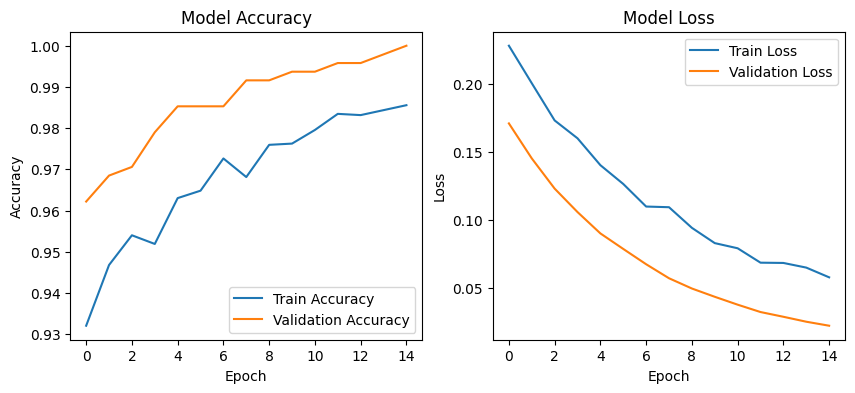

In [24]:
plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.plot(fine_tune_history.history['accuracy'], label='Train Accuracy')
plt.plot(fine_tune_history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(fine_tune_history.history['loss'], label='Train Loss')
plt.plot(fine_tune_history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()
